# Part 3: JIT Compilation — Making It Fast

**Goal**: Learn how `jit` turns your JAX function into an optimized compiled program. By the end, you'll understand tracing, jaxpr, TracerErrors, and have a JIT-compiled training loop that's 10-100x faster than the uncompiled version from Notebook 02.

---

## Table of Contents

1. **JIT Compilation — Making It Fast** — dispatch overhead, what jit does
2. **How Tracing Works** — tracers, jaxpr, caching
3. **When JIT Breaks** — TracerError, dynamic shapes, side effects, static args
4. **Common Misconceptions**
5. **Capstone: JIT-Compiled Training Step**
6. **Summary — What To Do Next**

---

> **Prerequisites**: This notebook builds on **Notebook 02: Autodiff**. We'll reuse the MLP and training step from the Notebook 02 capstone.

In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"JAX version: {jax.__version__}")
print(f"Devices:     {jax.devices()}")


JAX version: 0.9.2
Devices:     [CpuDevice(id=0)]


In [2]:
# @title Reconstruct MLP from Notebook 01 { display-mode: "form" }

def init_mlp_params(key, layer_sizes):
    """Initialize MLP parameters with He initialization."""
    params = []
    for i in range(len(layer_sizes) - 1):
        key, w_key, b_key = jax.random.split(key, 3)
        fan_in = layer_sizes[i]
        fan_out = layer_sizes[i + 1]
        w = jax.random.normal(w_key, (fan_in, fan_out)) * jnp.sqrt(2.0 / fan_in)
        b = jnp.zeros(fan_out)
        params.append((w, b))
    return params

def mlp_forward(params, x):
    """Forward pass through an MLP."""
    for i, (w, b) in enumerate(params):
        x = x @ w + b
        if i < len(params) - 1:
            x = jnp.maximum(x, 0)
    return x

# Same architecture and seed as Notebook 01
key = jax.random.PRNGKey(42)
layer_sizes = [8, 64, 32, 1]
params = init_mlp_params(key, layer_sizes)

print("MLP reconstructed: ", " → ".join(str(s) for s in layer_sizes))


MLP reconstructed:  8 → 64 → 32 → 1


In [3]:
# Reconstruct mse_loss from Notebook 02 required for benchmarking
def mse_loss(params, x, y):
    pred = mlp_forward(params, x)
    return jnp.mean((pred - y) ** 2)

---

# 5. JIT Compilation — Making It Fast

Without [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), every JAX operation dispatches individually to the backend — one Python → XLA round trip per operation. With [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), JAX **traces** your function once, compiles the entire computation graph, and executes the optimized version on subsequent calls.

> **jit doesn't change what your function computes. It changes how fast it computes it.**


In [4]:
import time

# Generate test data
key = jax.random.PRNGKey(0)
x_test = jax.random.normal(key, (8,))

# Non-jitted
def train_step_nojit(params, x, y, lr=0.01):
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)
    new_params = [(w - lr * dw, b - lr * db) for (w, b), (dw, db) in zip(params, grads)]
    return new_params, loss

# Jitted
# The @ decorator tells Python to pass this through jax.jit() implicitly
@jax.jit
def train_step_jit(params, x, y, lr=0.01):
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)
    new_params = [(w - lr * dw, b - lr * db) for (w, b), (dw, db) in zip(params, grads)]
    return new_params, loss

y_test = jnp.array(1.0)

# Warm up (first call includes compilation)
_ = train_step_nojit(params, x_test, y_test)
_ = train_step_jit(params, x_test, y_test)

# Benchmark
n_iters = 500
start = time.time()
p = params
for _ in range(n_iters):
    p, _ = train_step_nojit(p, x_test, y_test)
nojit_time = time.time() - start

start = time.time()
p = params
for _ in range(n_iters):
    p, _ = train_step_jit(p, x_test, y_test)
    # Need to block on last iteration to ensure all work is done
jax.tree.map(lambda x: x.block_until_ready(), p)
jit_time = time.time() - start

print(f"{'Method':<20} | {'Time':>10} | {'Per step':>12}")
print("-" * 50)
print(f"{'Without jit':<20} | {nojit_time:>8.3f} s | {nojit_time/n_iters*1000:>9.3f} ms")
print(f"{'With jit':<20} | {jit_time:>8.3f} s | {jit_time/n_iters*1000:>9.3f} ms")
print(f"{'Speedup':<20} | {nojit_time/jit_time:>9.1f}x |")



Method               |       Time |     Per step
--------------------------------------------------
Without jit          |    0.806 s |     1.612 ms
With jit             |    0.004 s |     0.008 ms
Speedup              |     194.8x |


## How Tracing Works

When you first call a jitted function, JAX feeds **tracer objects** (abstract placeholders that carry shape and dtype but no values) through your function. It records every operation to build a computation graph (called a **jaxpr**), then hands that graph to XLA for compilation.

The compiled version is cached. Subsequent calls with the same shapes and dtypes skip tracing and compilation entirely.

<br>

```mermaid
flowchart LR
    A[Python JAX Code] -->|First call| B(JAX Tracer)
    B -->|Records abstract ops| C{jaxpr IR}
    C -->|Handed off| D[XLA Compiler]
    D --> E((Compiled Binary))
    
    A -->|Subsequent calls| E
    E --> F[Optimized Execution]
    
    style A fill:#f9f9f9,stroke:#333
    style C fill:#fff3cd,stroke:#ffc107
    style E fill:#d4edda,stroke:#28a745
```


In [5]:
@jax.jit
def demo_tracing(x):
    print(f"  TRACING with x = {x}")  # This runs during tracing only
    result = x * 2 + 1
    return result

print("--- First call (traces + compiles): ---")
r1 = demo_tracing(jnp.array(5.0))
print(f"  Result: {r1}")

print("\n--- Second call (uses cached compilation): ---")
r2 = demo_tracing(jnp.array(10.0))
print(f"  Result: {r2}")

print("\n--- Third call with DIFFERENT SHAPE (re-traces): ---")
r3 = demo_tracing(jnp.array([1.0, 2.0]))
print(f"  Result: {r3}")

print("\nThe print ran during tracing (calls 1 and 3), not during cached execution (call 2).")
print("Notice: during tracing, x shows as a Traced<...> object, not a value.")



--- First call (traces + compiles): ---
  TRACING with x = JitTracer(~float32[])
  Result: 11.0

--- Second call (uses cached compilation): ---
  Result: 21.0

--- Third call with DIFFERENT SHAPE (re-traces): ---
  TRACING with x = JitTracer(float32[2])
  Result: [3. 5.]

The print ran during tracing (calls 1 and 3), not during cached execution (call 2).
Notice: during tracing, x shows as a Traced<...> object, not a value.


## make_jaxpr — Reading JAX's IR

[`jax.make_jaxpr`](https://jax.readthedocs.io/en/latest/_autosummary/jax.make_jaxpr.html) shows you the computation graph that JIT would compile. It's the single best debugging tool for understanding what JAX sees.


**How to read a jaxpr output:**
- Each `let a = op(b, c)` line is one XLA primitive operation
- The names (`a`, `b`, `c`) are abstract tracers — placeholders with shape and dtype, not values
- The final `in [...]` line lists the outputs of the function

You don't need to fully understand jaxpr syntax — just look for which operations appear and in what order.


In [6]:
def simple_fn(x, y):
    z = x * y + 1
    return jnp.sin(z)

print("jaxpr for simple_fn(float32, float32):")
print(jax.make_jaxpr(simple_fn)(jnp.float32(1.0), jnp.float32(2.0)))

print("\nReading this:")
print("  a:f32[] = mul(x, y)         ← z = x * y")
print("  b:f32[] = add(a, 1.0)       ← z + 1")
print("  c:f32[] = sin(b)            ← sin(z + 1)")
print("  return c")
print("\nNo Python control flow, no side effects — just the math.")



jaxpr for simple_fn(float32, float32):
{ lambda ; a:f32[] b:f32[]. let
    c:f32[] = mul a b
    d:f32[] = add c 1.0:f32[]
    e:f32[] = sin d
  in (e,) }

Reading this:
  a:f32[] = mul(x, y)         ← z = x * y
  b:f32[] = add(a, 1.0)       ← z + 1
  c:f32[] = sin(b)            ← sin(z + 1)
  return c

No Python control flow, no side effects — just the math.


---

# 6. When JIT Breaks — TracerError, Recompilation, and Static Args

JIT is powerful, but it has rules. When you violate them, you get `TracerError` — JAX's way of saying "I can't trace this."

## The Three Most Common TracerError Causes

### Cause 1: Data-Dependent Control Flow

During tracing, `x` is an **abstract placeholder** (a tracer object) — it carries shape and dtype but has no concrete value. So `x > 0` returns another tracer, not `True` or `False`. Python's `if` statement can't branch on a tracer.



In [7]:
# This FAILS — the if/else depends on the VALUE of x, which is unknown at trace time
def bad_relu(x):
    if x > 0:       # Python if on a traced value → TracerError
        return x
    else:
        return 0.0

try:
    jax.jit(bad_relu)(jnp.array(1.0))
except jax.errors.TracerBoolConversionError as e:
    print(f"Error: {type(e).__name__}")
    print(f"  {str(e)[:200]}...")

# Fix: use jnp.where (always evaluates both branches)
def good_relu(x):
    return jnp.where(x > 0, x, 0.0)

print(f"\nFixed with jnp.where: {jax.jit(good_relu)(jnp.array(1.0))}")
print(f"Also works for negative: {jax.jit(good_relu)(jnp.array(-1.0))}")



Error: TracerBoolConversionError
  Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function bad_relu at /var/folders/xv/10y3vjpx44l9f9ctfbxcvd8c0000gn/T/ipykernel_51541/288865114.py:...

Fixed with jnp.where: 1.0
Also works for negative: 0.0


### Cause 2: Dynamic Shapes

JAX traces with **fixed shapes**. You can't create arrays whose size depends on input values.


In [8]:
# This FAILS — jnp.zeros(n) where n is traced
def bad_dynamic(n):
    return jnp.zeros(n)  # n must be known at trace time

try:
    jax.jit(bad_dynamic)(3)
except Exception as e:
    print(f"Error: {type(e).__name__}")
    print(f"  {str(e)[:200]}...")

# Fix: use static_argnums to make n a compile-time constant
@jax.jit
def good_dynamic(x, n):
    # Pad or slice x to length n — shape is determined by x's shape, not n's value
    return x[:n]

# Or use static_argnums
fixed_dynamic = jax.jit(bad_dynamic, static_argnums=(0,))
print(f"\nFixed with static_argnums: {fixed_dynamic(3)}")



Error: TypeError
  Shapes must be 1D sequences of concrete values of integer type, got (JitTracer(~int32[]),).
If using `jit`, try using `static_argnums` or applying `jit` to smaller subfunctions.
The error occurred whi...

Fixed with static_argnums: [0. 0. 0.]


### Cause 3: Side Effects

As we saw in [Notebook 01](01_foundations.ipynb) — side effects don't cause TracerError, but they produce silently wrong results, which is worse.


## static_argnums — The Escape Hatch

When an argument must be known at trace time (because it determines shapes or control flow), mark it as static. JAX will re-trace and re-compile whenever that argument changes.

> **Warning**: If a static argument takes many different values, you'll compile many versions. This is a compilation cache explosion and it will make your program slow. For example, if you mark `batch_size` as static and call with 8, 16, 24, 32, 64 … JAX compiles a fresh version for each — potentially dozens or hundreds of compilations that accumulate silently.


In [9]:
def add_ones(x, n):
    print(f"  Tracing with n={n}")  # Only runs during tracing
    return x + jnp.ones(n)

# n must be static because it determines the shape of jnp.ones(n)
add_ones_static = jax.jit(add_ones, static_argnums=(1,))

print("--- Same n: traces once, then cached ---")
print(f"Result: {add_ones_static(jnp.array([1.0, 2.0, 3.0]), 3)}")
print(f"Result: {add_ones_static(jnp.array([4.0, 5.0, 6.0]), 3)}")

print("\n--- Different n: must re-trace ---")
print(f"Result: {add_ones_static(jnp.array([1.0, 2.0]), 2)}")

print("\nEach unique value of n triggers a new compilation.")



--- Same n: traces once, then cached ---
  Tracing with n=3
Result: [2. 3. 4.]
Result: [5. 6. 7.]

--- Different n: must re-trace ---
  Tracing with n=2
Result: [2. 3.]

Each unique value of n triggers a new compilation.


## What Triggers Recompilation

| Change | Recompiles? |
|---|---|
| Different **values** (same shape/dtype) | No — uses cached version |
| Different **shape** | Yes |
| Different **dtype** | Yes |
| Different **static arg value** | Yes |
| Different **number of args** | Yes |

This is why `block_until_ready()` matters for benchmarking — the first call includes compilation time, subsequent calls don't.


---

# 4. Common Misconceptions

## Misconception: "jit makes everything faster"

JIT has overhead: tracing, compilation, and dispatching results back to Python. For tiny functions called once, this overhead dominates. JIT shines when:
- The function does substantial computation (matrix operations, many ops)
- The function is called many times with the same shapes
- The function contains operations that XLA can fuse

If your function is a single [`jnp.dot`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.dot.html), JIT may not help — the dispatch overhead for one operation is already low.


## Misconception: "TracerError means my code is wrong"

TracerError means your code isn't *traceable as written*. The computation might be perfectly correct — it just uses patterns JAX can't trace (data-dependent shapes, Python control flow on traced values). The fix is usually to restructure using JAX's control flow primitives ([`jnp.where`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.where.html), `lax.cond`, `lax.scan`) or `static_argnums`. We'll cover these in depth in Notebook 06.


---

# 5. Capstone: JIT-Compiled Training Step

Let's take the uncompiled training loop from [Notebook 02](02_autodiff.ipynb) and add `@jax.jit`. We'll measure the before and after to make the speedup concrete.

In [10]:
# @title Generate Synthetic Regression Data { display-mode: "form" }

def generate_data(key, n_samples=500, noise_scale=0.1):
    """Generate y = sin(x_0) + 0.5*cos(x_1) + noise, with 8 input features."""
    key, x_key, noise_key = jax.random.split(key, 3)
    x = jax.random.normal(x_key, (n_samples, 8))
    # Target depends on first two features only — the network must learn to ignore the rest
    y = jnp.sin(x[:, 0]) + 0.5 * jnp.cos(x[:, 1]) + noise_scale * jax.random.normal(noise_key, (n_samples,))
    return x, y

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)
x_train, y_train = generate_data(data_key)

print(f"Training data: x shape {x_train.shape}, y shape {y_train.shape}")
print(f"Target range: [{y_train.min().item():.2f}, {y_train.max().item():.2f}]")



Training data: x shape (500, 8), y shape (500,)
Target range: [-1.47, 1.67]


In [11]:
def mse_loss(params, x, y):
    """Batched MSE: average over all samples."""
    # Apply forward pass to each sample (simple loop — vmap version in Notebook 04)
    preds = jnp.array([mlp_forward(params, xi) for xi in x]).squeeze()  # .squeeze() strips out dangling length-1 dimensions
    return jnp.mean((preds - y) ** 2)

# The @ decorator tells Python to pass this through jax.jit() implicitly
@jax.jit
def train_step(params, x, y, lr=0.01):
    """One step of gradient descent.

    Returns:
        (updated_params, loss_value)
    """
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)

    # SGD update: param = param - lr * gradient
    # This works because grads has the same structure as params
    new_params = [
        (w - lr * dw, b - lr * db)
        for (w, b), (dw, db) in zip(params, grads)  # zip() structurally pairs the lists
    ]

    return new_params, loss

# Verify it works (and trigger compilation)
new_params, loss = train_step(params, x_train, y_train)
print(f"Initial loss: {loss.item():.4f}")
print(f"Params structure preserved: {[w.shape for w, b in new_params]}")



Initial loss: 3.2752
Params structure preserved: [(8, 64), (64, 32), (32, 1)]


In [12]:
# @title Train the MLP { display-mode: "form" }

# Re-initialize
key = jax.random.PRNGKey(42)
params = init_mlp_params(key, [8, 64, 32, 1])

# Training loop
n_epochs = 300
losses = []

for epoch in range(n_epochs):
    params, loss = train_step(params, x_train, y_train, lr=0.005)
    losses.append(loss.item())

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:>3d}: loss = {loss.item():.4f}")



Epoch   0: loss = 3.2752
Epoch  50: loss = 0.3377
Epoch 100: loss = 0.2317
Epoch 150: loss = 0.1817
Epoch 200: loss = 0.1537
Epoch 250: loss = 0.1350
Epoch 299: loss = 0.1222


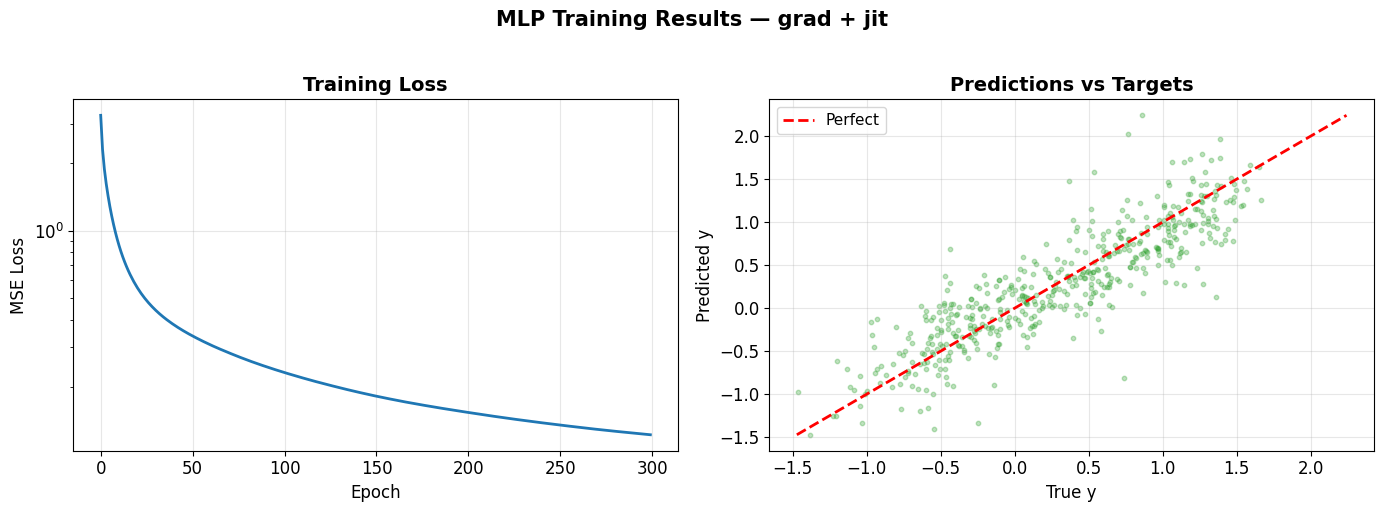

Final MSE: 0.1222

This training loop used:
  • value_and_grad to compute loss + gradients in one pass
  • @jax.jit to compile the entire training step
  • Pure functional updates (no mutation, new params each step)


In [13]:
# @title Visualize Training Progress { display-mode: "form" }

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses, linewidth=2, color='#1f77b4')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Predictions vs targets
preds = jnp.array([mlp_forward(params, xi) for xi in x_train]).squeeze()  # Flatten our (N, 1) prediction into (N,)
axes[1].scatter(np.array(y_train), np.array(preds), alpha=0.3, s=10, color='#2ca02c')
min_val = min(y_train.min().item(), preds.min().item())
max_val = max(y_train.max().item(), preds.max().item())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('True y', fontsize=12)
axes[1].set_ylabel('Predicted y', fontsize=12)
axes[1].set_title('Predictions vs Targets', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

fig.suptitle('MLP Training Results — grad + jit', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

final_loss = losses[-1]
print(f"Final MSE: {final_loss:.4f}")
print(f"\nThis training loop used:")
print(f"  • value_and_grad to compute loss + gradients in one pass")
print(f"  • @jax.jit to compile the entire training step")
print(f"  • Pure functional updates (no mutation, new params each step)")



---

# 6. Summary — What To Do Next

## Key Takeaways

1. **[`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) compiles your Python function into an optimized XLA program** — which runs far faster by eliminating Python overhead and fusing operations.
2. **JAX traces your code with abstract values** — any Python control flow (`if`, `for`) depending on data values will raise a `TracerError` because values are unknown at compile time.
3. **Use JAX control flow primitives** — replace `if` with `jax.lax.cond` and `for` with `jax.lax.scan` to bake control flow into the compiled graph.
4. **`static_argnums` is an escape hatch** — use it for configuration parameters, but beware of recompilation overhead if the value changes frequently.

## What's Next

In **[Notebook 04](04_vmap.ipynb): vmap — Vectorization**, we'll see another fundamental JAX transformation: `vmap`, which automatically vectorizes functions across batch dimensions, eliminating the need for manual array reshaping and broadcasting.

---

# Exercises

1. **TracerError debugging**: Write a jitted function that contains `if x > 0:` (where `x` is a traced array). Observe the TracerError. Fix it using `jax.lax.cond`.

2. **JIT warm-up**: Time a jitted function's first call vs. its second call using `block_until_ready()`. How much faster is the cached version?

3. **static_argnums trap**: Write a function that takes a `batch_size` parameter and mark it as static. Call it with 10 different batch sizes and observe how many compilations occur (use `print` at trace time).